## GPU Computing — Best Practices

### ****Exercise 1:** Matmul Kernel Progression**

****Goal:** Run three matmul kernels and see the optimization ladder.**

1. **Run `matmul_benchmark.py` (on Moodle) — it times kernels 1, 2, and 3 plus `a @ b`**

Note that the filename has changed to `e1_matmul_benchmark.py`

In [1]:
%run -i e1_matmul_benchmark.py

Device: gfx1035
N=1024  TILE_SIZE=16  runs=3



/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


matmul1 (naive):        99.4 ms
matmul2 (row-based):    130.5 ms
matmul3 (tiled):        7.3 ms
numpy matmul:           7.8 ms

Saved: matmul_benchmark.png


2. **Look at the bar chart saved to `matmul_benchmark.png`**

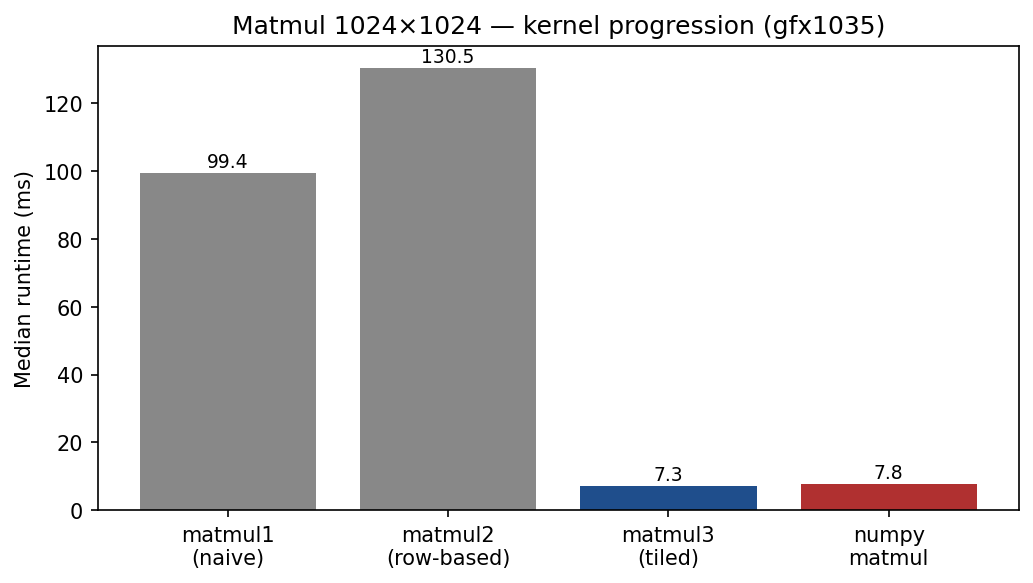

In [2]:
from IPython.display import display, Image

display(Image("matmul_benchmark.png"))

3. **Understand why each step is faster (see next slide for a diagram):**

- **Kernel 1 → kernel 2: private accumulator — row of A stays in registers, fewer global reads**

- **Kernel 2 → kernel 3: tiled local memory — each A/B element loaded from global memory once, reused `TILE_SIZE` times**

The titled allows for more optimised memory access patterns (i.e using the registers), making it a tad bit faster than numpy on the cpu.

**Questions to discuss:**

- **What is the speedup from kernel 1 to kernel 2? From kernel 2 to kernel 3?**

$$ S_{1 \rightarrow 2} = \frac{99.4 \space \text{ms}}{130.5 \space \text{ms}} = 0.76 \times $$

$$ S_{2 \rightarrow 3} = \frac{130.5 \space \text{ms}}{7.3 \space \text{ms}} = 17.88 \times $$

- **How does the tiled kernel (3) compare to `a @ b`?**

$$ S_{\text{a@b} \rightarrow 3} = \frac{7.8 \space \text{ms}}{7.3 \space \text{ms}} = 1.07 \times $$

Running the matrix multiplication on the GPU is slightly faster using the tiled kernel.

- **Why does NumPy win or lose?**

NumPy losses for me, but it was a close call. With mamba, NumPy is compiled against acceleration libs such as OpenBLAS likely using hardware vector acceleration (such as avx512), which my CPU does not support. If it did I suspect that NumPy would have been faster.

****Done?** Discuss the bar chart with a neighbour → move on to E2**

### ****Exercise 2:** Tile Size Sweep**

****Goal:** Vary `TILE_SIZE` and observe the effect on kernel 3 runtime.**

**Change the constant at the top of matmul_benchmark.py:**
```python
TILE_SIZE = 8 # try also 16 and 32
```
**Check the work-group size limit before running:**
```python
ctx = cl.create_some_context(interactive=False)
dev = ctx.devices[0]
print(f"max_work_group_size: {dev.max_work_group_size}") 
# TILE_SIZE^2 must not exceed this value
```
**Local memory budget (check if device is limited):**
```python
print(f"local_mem_size: {dev.local_mem_size // 1024
```

****Before sweeping:** run the introspection script from L10 and note for your device:**

- **max_work_group_size — `TILE SIZE`<sup>2</sup> must not exceed this**

- **`local_mem_size` — each tile pair uses $2 \times T^2 \times 4$ bytes**

1. **Edit e1 `matmul_benchmark.py`: change `TILE_SIZE` to 2, 4, 8, 16, 32 (or as high as your device allows)**

2. **Record the kernel 3 runtime each time**

3. **Plot runtime vs tile size (or note the three numbers)**

**Questions to discuss:**

- **Which tile size gives the best runtime?**

- **Can you explain the optimum (or the ceiling) in terms of your device’s `max_work_group_size` or `local_mem_size` (see `introspection.py` script from L10)?**

- **Does a larger tile always help? Why or why not?**

****Done?** Discuss with a neighbour → move on to E3**

### ****Exercise 3:** Parallel Reduction**

**Goal: Implement `sum(x)` and `sum(x^2)` for a 1M-element float32 array in OpenCL with both naive and tree reduction (explained below) and compare to numpy (CPU).**

> **Hint: Use 1 kernel template, substitute operation via an f-string: `LOAD = "v"` or `LOAD = "v*v"`.**

**Naive (start here):**

```c
__kernel void reduce_naive(
    __global const float* data,
    __global float* partial, int n)
{
    __local float scratch[WG];
    int gid = get_global_id(0);
    int lid = get_local_id(0);
    float v = (gid < n) ? data[gid] : 0.f;
    scratch[lid] = {LOAD};
    barrier(CLK_LOCAL_MEM_FENCE);
    if (lid == 0) {
        float s = 0.f;
        for (int i = 0; i < WG; ++i)
            s += scratch[i];
        partial[get_group_id(0)] = s;
    }
}
```

- **Each work-item loads one element into `__local float scratch[WG]`**

- **Work-item 0 serially sums the entire scratch array and writes one partial result to global memory**

- **The host reads one partial result per work-group and reduces with `np.sum`**

**Tree reduction:**

```c
__kernel void reduce_tree(
    __global const float* data,
    __global float* partial, int n)
{
    __local float scratch[WG];
    int gid = get_global_id(0);
    int lid = get_local_id(0);
    float v = (gid < n) ? data[gid] : 0.f;
    scratch[lid] = {LOAD};
    barrier(CLK_LOCAL_MEM_FENCE);
    for (int off = WG/2; off > 0; off >>= 1) {
        if (lid < off)
            scratch[lid] += scratch[lid + off];
        barrier(CLK_LOCAL_MEM_FENCE);
    }
    if (lid == 0)
        partial[get_group_id(0)] = scratch[0];
}
```

- **Same load into scratch; reduce with a binary tree and `barrier(CLK LOCAL MEM FENCE)`**

- **Work-item 0 writes the group result; host reduces with `np.sum` as before**

**Questions:**

- **Does GPU `sum(x)` beat `np.sum`? How does tree compare to naive?**

- **Does GPU `sum(x^2)` beat `np.sum(data**2)`? Why the difference?**

****Done?** Discuss with a neighbour**